# 索引可视化工具

随机选择 index 文件夹下的 JSON 文件，绘制切片布局示意图。


In [1]:
import json
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
INDEX_DIR = Path("/Users/weixianfu/Documents/Datas/mtsd-resized/val/index")


In [3]:
def draw_tile_layout(index_path: Path):
    """根据单个索引JSON绘制切片布局"""
    with open(index_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    h, w = data["original_shape"]
    slices = data["slices"]
    full_resized = data["full_resized"]
    
    # 打印信息
    print(f"=" * 60)
    print(f"Image ID: {index_path.stem}")
    print(f"Original Shape: {w} x {h} (W x H)")
    print(f"Number of Tiles: {len(slices)}")
    print(f"Full Resized: scale={full_resized['scale_factor']:.4f}, padding={full_resized['padding']}")
    print(f"-" * 60)
    for i, s in enumerate(slices):
        x1, y1, x2, y2 = s["roi"]
        print(f"  Tile {i}: {s['filename']} -> ROI [{x1}, {y1}, {x2}, {y2}] ({x2-x1}x{y2-y1})")
    print()
    
    # 绘图
    fig, ax = plt.subplots(1, 1, figsize=(12, 12 * h / w))
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)  # y轴反转，原点在左上角
    ax.set_aspect("equal")
    ax.set_facecolor("#f0f0f0")
    ax.set_title(f"{index_path.stem}\n{w} x {h}", fontsize=14)
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    
    # 绘制原图边界
    rect_bg = patches.Rectangle((0, 0), w, h, linewidth=2, edgecolor="black", facecolor="white")
    ax.add_patch(rect_bg)
    
    # 颜色列表
    colors = plt.cm.tab10.colors
    
    # 绘制每个tile
    for i, s in enumerate(slices):
        x1, y1, x2, y2 = s["roi"]
        color = colors[i % len(colors)]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor=color, alpha=0.2
        )
        ax.add_patch(rect)
        # 标注tile编号
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(cx, cy, str(i), fontsize=16, ha="center", va="center", 
                color="black", fontweight="bold",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()


def visualize_random_indexes(n: int = 1, index_dir: Path = INDEX_DIR):
    """随机选择n个索引文件并可视化"""
    json_files = list(index_dir.glob("*.json"))
    print(f"Index 文件夹共有 {len(json_files)} 个 JSON 文件")
    
    selected = random.sample(json_files, min(n, len(json_files)))
    print(f"随机选择 {len(selected)} 个文件:\n")
    
    for json_path in selected:
        draw_tile_layout(json_path)


Index 文件夹共有 5320 个 JSON 文件
随机选择 3 个文件:

Image ID: fully_val_ZivT3EWnRE5a2CblxWm_Jw
Original Shape: 3264 x 2448 (W x H)
Number of Tiles: 9
Full Resized: scale=0.3922, padding=[0.0, 160.0]
------------------------------------------------------------
  Tile 0: fully_val_ZivT3EWnRE5a2CblxWm_Jw_0.jpg -> ROI [0, 0, 1280, 1280] (1280x1280)
  Tile 1: fully_val_ZivT3EWnRE5a2CblxWm_Jw_1.jpg -> ROI [1024, 0, 2304, 1280] (1280x1280)
  Tile 2: fully_val_ZivT3EWnRE5a2CblxWm_Jw_2.jpg -> ROI [1984, 0, 3264, 1280] (1280x1280)
  Tile 3: fully_val_ZivT3EWnRE5a2CblxWm_Jw_3.jpg -> ROI [0, 1024, 1280, 2304] (1280x1280)
  Tile 4: fully_val_ZivT3EWnRE5a2CblxWm_Jw_4.jpg -> ROI [1024, 1024, 2304, 2304] (1280x1280)
  Tile 5: fully_val_ZivT3EWnRE5a2CblxWm_Jw_5.jpg -> ROI [1984, 1024, 3264, 2304] (1280x1280)
  Tile 6: fully_val_ZivT3EWnRE5a2CblxWm_Jw_6.jpg -> ROI [0, 1168, 1280, 2448] (1280x1280)
  Tile 7: fully_val_ZivT3EWnRE5a2CblxWm_Jw_7.jpg -> ROI [1024, 1168, 2304, 2448] (1280x1280)
  Tile 8: fully_val_ZivT3E

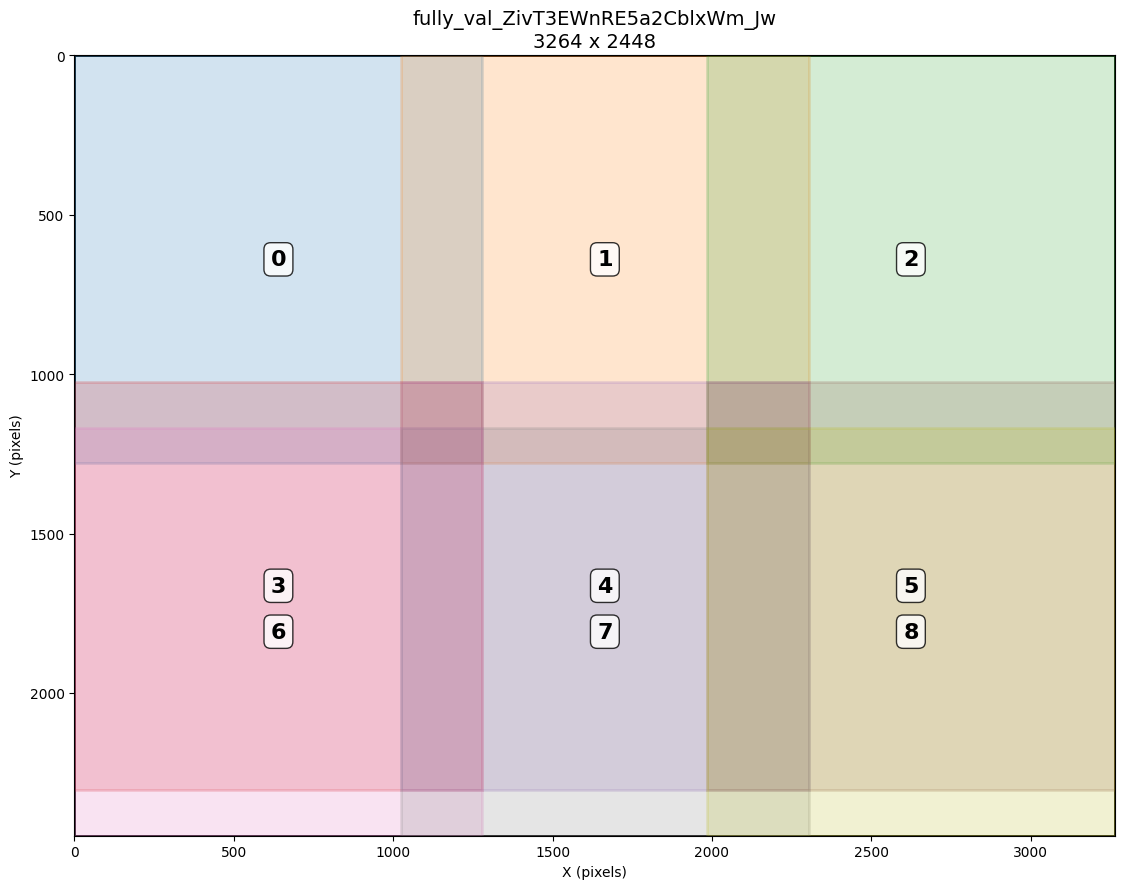

Image ID: fully_val_Vv_G2zD0QB5rPTwtsTLbAw
Original Shape: 4000 x 3000 (W x H)
Number of Tiles: 12
Full Resized: scale=0.3200, padding=[0.0, 160.0]
------------------------------------------------------------
  Tile 0: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_0.jpg -> ROI [0, 0, 1280, 1280] (1280x1280)
  Tile 1: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_1.jpg -> ROI [1024, 0, 2304, 1280] (1280x1280)
  Tile 2: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_2.jpg -> ROI [2048, 0, 3328, 1280] (1280x1280)
  Tile 3: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_3.jpg -> ROI [2720, 0, 4000, 1280] (1280x1280)
  Tile 4: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_4.jpg -> ROI [0, 1024, 1280, 2304] (1280x1280)
  Tile 5: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_5.jpg -> ROI [1024, 1024, 2304, 2304] (1280x1280)
  Tile 6: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_6.jpg -> ROI [2048, 1024, 3328, 2304] (1280x1280)
  Tile 7: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_7.jpg -> ROI [2720, 1024, 4000, 2304] (1280x1280)
  Tile 8: fully_val_Vv_G2zD0QB5rPTwtsTLbAw_8.jpg -> ROI [0, 1720,

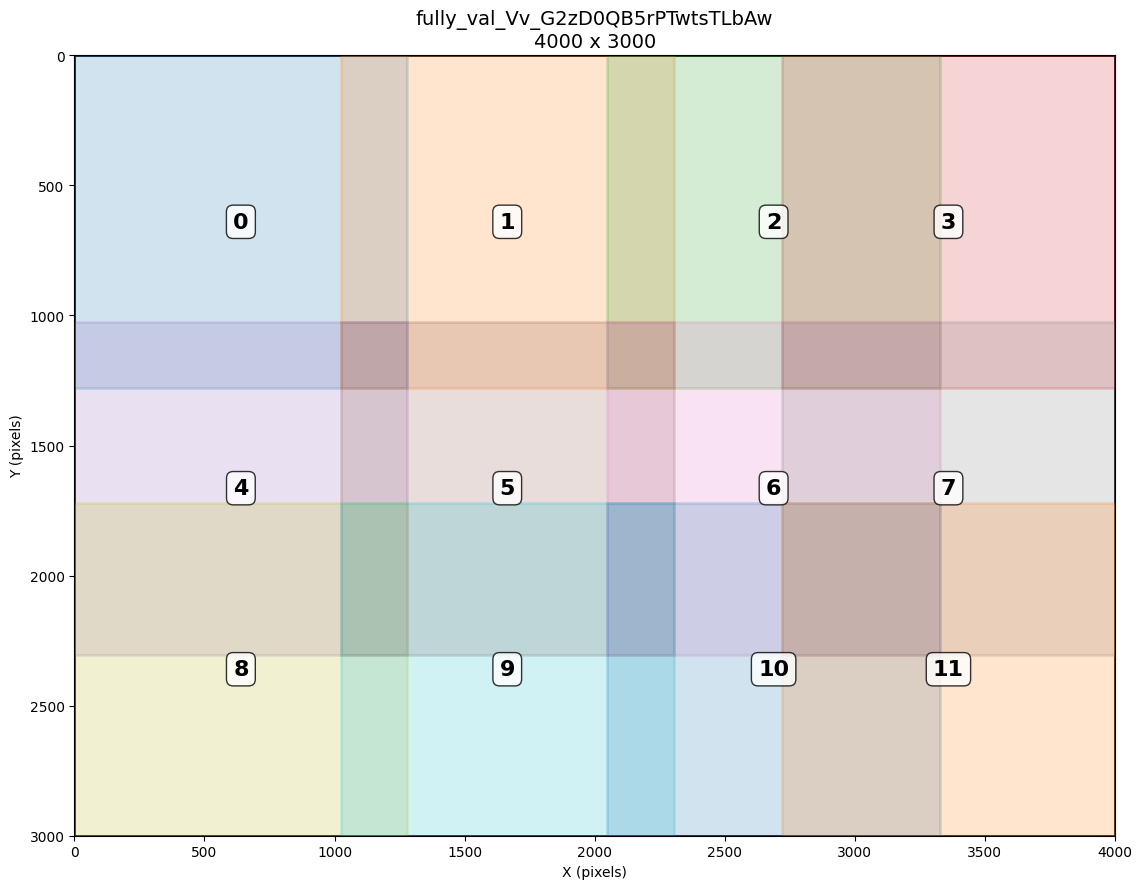

Image ID: fully_val_wCwes5X34Bm3xZ_0ml_ZuA
Original Shape: 4160 x 3120 (W x H)
Number of Tiles: 12
Full Resized: scale=0.3077, padding=[0.0, 160.0]
------------------------------------------------------------
  Tile 0: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_0.jpg -> ROI [0, 0, 1280, 1280] (1280x1280)
  Tile 1: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_1.jpg -> ROI [1024, 0, 2304, 1280] (1280x1280)
  Tile 2: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_2.jpg -> ROI [2048, 0, 3328, 1280] (1280x1280)
  Tile 3: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_3.jpg -> ROI [2880, 0, 4160, 1280] (1280x1280)
  Tile 4: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_4.jpg -> ROI [0, 1024, 1280, 2304] (1280x1280)
  Tile 5: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_5.jpg -> ROI [1024, 1024, 2304, 2304] (1280x1280)
  Tile 6: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_6.jpg -> ROI [2048, 1024, 3328, 2304] (1280x1280)
  Tile 7: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_7.jpg -> ROI [2880, 1024, 4160, 2304] (1280x1280)
  Tile 8: fully_val_wCwes5X34Bm3xZ_0ml_ZuA_8.jpg -> ROI [0, 1840,

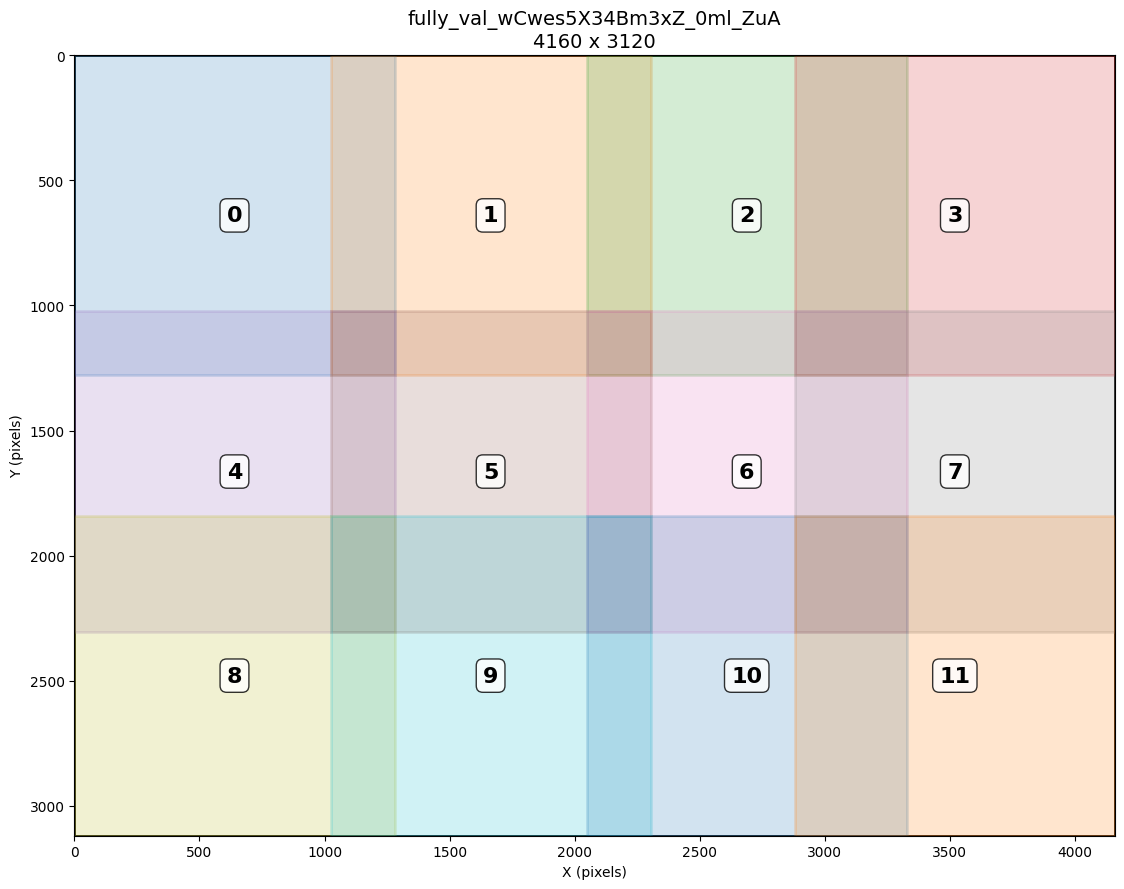

In [4]:
# 随机可视化 3 个索引
visualize_random_indexes(n=3)
